<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/12_gradcam_cnn_vs_resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grad-CAM: CNN vs ResNet18 na challenges.csv (gdje CNN pogađa a ResNet greši)

Test pretpostavke da CNN od nule bolje radi na `challenges.csv` (32 najteže slike) jer se pri odluci
oslanja i na pozadinu, ne samo na lik — dok se ResNet18 fokusira uže, samo na lik, i zato ponekad
promaši kad je lik nejasan/djelimično zaklonjen. Tražimo slike gdje je CNN tačno pogodio a ResNet18
pogriješio, i poredimo Grad-CAM (gdje se koji model fokusira) na baš tim slikama.

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
!pip install -U kaggle -q
!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
!unzip -q tom-and-jerry-image-classification.zip -d data/

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "bibic.ilinka@gmail.com"
!git config user.name "Ika"

!ls models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.6 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:03<00:00, 130MB/s]

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 199, done.
remote: Counting objects: 100% (87/87), done.
remote: Compressing objects: 100% (81/81), done.
remote: Total 199 (delta 41), reused 21 (delta 4), pack-reused 112 (from 2)
Receiving objects: 100% (199/199), 279.41 MiB | 32.36 MiB/s, done.
Resolving deltas: 100% (90/90), done.
Updating files: 100% (29/29), done.
/content/Tom-and-Jerry-Character-Classification
cnn_scratch.pt		   resnet18_transfer.pt  svm_final.joblib
resnet18_transfer_10ep.pt  rf_final.joblib	 svm_scaler.joblib


Učitavanje `challenges.csv` i `data_split.csv`, provjera da je svih 32 slika zaista izuzeto iz train/val/test.

In [2]:
import pandas as pd

challenges = pd.read_csv('/content/data/challenges.csv')
split_df = pd.read_csv('data_split.csv')

print("challenges.csv:", challenges.shape)

merged = challenges.merge(split_df[['filename', 'split']], left_on='image_name', right_on='filename', how='left')
print("\nRaspodela po split-u:")
print(merged['split'].value_counts(dropna=False))

challenges.csv: (32, 2)

Raspodela po split-u:
split
excluded    32
Name: count, dtype: int64


Priprema putanja do slika i stvarnih labela za tih 32 challenge slike.

In [3]:
folder_map = {'tom': 'tom', 'jerry': 'jerry', 'both': 'tom_jerry_1', 'neither': 'tom_jerry_0'}
base_dir = '/content/data/tom_and_jerry/tom_and_jerry/'

challenge_df = split_df[split_df['split'] == 'excluded'].reset_index(drop=True)
challenge_df['filepath'] = challenge_df.apply(lambda r: base_dir + folder_map[r['class']] + '/' + r['filename'], axis=1)

y_challenge = challenge_df['class'].values

print("Broj challenge slika:", len(challenge_df))
print(challenge_df[['filename', 'class']])

Broj challenge slika: 32
         filename  class
0     frame46.jpg    tom
1    frame360.jpg  jerry
2    frame715.jpg    tom
3   frame1684.jpg    tom
4   frame1685.jpg    tom
5   frame1686.jpg    tom
6   frame1768.jpg    tom
7   frame1794.jpg  jerry
8   frame1795.jpg  jerry
9   frame2154.jpg    tom
10  frame2160.jpg    tom
11  frame2215.jpg    tom
12  frame2231.jpg  jerry
13  frame2234.jpg  jerry
14  frame2941.jpg  jerry
15  frame2942.jpg  jerry
16  frame2943.jpg  jerry
17  frame2944.jpg  jerry
18  frame2946.jpg    tom
19  frame2947.jpg    tom
20  frame2948.jpg    tom
21  frame2949.jpg    tom
22  frame2950.jpg    tom
23  frame2951.jpg    tom
24  frame4579.jpg    tom
25  frame4580.jpg    tom
26  frame4581.jpg    tom
27  frame5399.jpg  jerry
28  frame5400.jpg  jerry
29  frame5401.jpg  jerry
30  frame5408.jpg  jerry
31  frame5436.jpg  jerry


Učitavamo oba duboka modela (CNN od nule i ResNet18) sa sačuvanim težinama.

In [4]:
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

IMG_SIZE = 64
class SmallCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2); self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * (IMG_SIZE//8) * (IMG_SIZE//8), 128)
        self.fc2 = nn.Linear(128, n)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

cnn = SmallCNN(4).to(device)
cnn.load_state_dict(torch.load('models/cnn_scratch.pt', map_location=device))
cnn.eval()

resnet = models.resnet18(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 4)
resnet.load_state_dict(torch.load('models/resnet18_transfer.pt', map_location=device))
resnet = resnet.to(device)
resnet.eval()

# VAŽNO: CNN i ResNet imaju RAZLIČIT redosled klasa (svaki koristi svoj redosled iz svog treninga) —
# moraju se prevesti nazad u imena OVIM tačnim rečnicima, inače bi predikcije bile tiho pomiješane
cnn_idx = {0: 'both', 1: 'jerry', 2: 'neither', 3: 'tom'}
res_idx = {0: 'tom', 1: 'jerry', 2: 'both', 3: 'neither'}

print("Oba modela učitana.")

Device: cpu
Oba modela učitana.


Predikcija oba modela (CNN i ResNet18) na svih 32 challenge slike, i provjera tačnosti po slici.

In [5]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

class ImgDS(Dataset):
    def __init__(self, df, tf):
        self.paths = df['filepath'].values
        self.tf = tf
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB'))

def predict_deep(model, tf, idx_to_class):
    loader = DataLoader(ImgDS(challenge_df, tf), batch_size=32, shuffle=False, num_workers=2)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb in loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().tolist())
    return [idx_to_class[i] for i in preds]

cnn_tf = T.Compose([T.Resize((64, 64)), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])
res_tf = T.Compose([T.Resize((224, 224)), T.ToTensor(),
                     T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

pred_cnn = predict_deep(cnn, cnn_tf, cnn_idx)
pred_res = predict_deep(resnet, res_tf, res_idx)

challenge_df['pred_cnn'] = pred_cnn
challenge_df['pred_resnet'] = pred_res
challenge_df['cnn_tacno'] = challenge_df['pred_cnn'] == challenge_df['class']
challenge_df['resnet_tacno'] = challenge_df['pred_resnet'] == challenge_df['class']

print(challenge_df[['filename', 'class', 'pred_cnn', 'cnn_tacno', 'pred_resnet', 'resnet_tacno']])

         filename  class pred_cnn  cnn_tacno pred_resnet  resnet_tacno
0     frame46.jpg    tom  neither      False        both         False
1    frame360.jpg  jerry  neither      False     neither         False
2    frame715.jpg    tom     both      False         tom          True
3   frame1684.jpg    tom      tom       True         tom          True
4   frame1685.jpg    tom      tom       True         tom          True
5   frame1686.jpg    tom      tom       True         tom          True
6   frame1768.jpg    tom      tom       True     neither         False
7   frame1794.jpg  jerry    jerry       True       jerry          True
8   frame1795.jpg  jerry    jerry       True       jerry          True
9   frame2154.jpg    tom      tom       True         tom          True
10  frame2160.jpg    tom      tom       True         tom          True
11  frame2215.jpg    tom      tom       True     neither         False
12  frame2231.jpg  jerry  neither      False       jerry          True
13  fr

Filtriramo slike gdje je CNN tačno pogodio a ResNet18 pogriješio — baš te ćemo koristiti za Grad-CAM poređenje.

In [6]:
cnn_bolji = challenge_df[challenge_df['cnn_tacno'] & ~challenge_df['resnet_tacno']]
print("Broj slika gdje CNN pogađa a ResNet greši:", len(cnn_bolji))
print(cnn_bolji[['filename', 'class', 'pred_cnn', 'pred_resnet']])

Broj slika gdje CNN pogađa a ResNet greši: 5
         filename  class pred_cnn pred_resnet
6   frame1768.jpg    tom      tom     neither
11  frame2215.jpg    tom      tom     neither
15  frame2942.jpg  jerry    jerry     neither
16  frame2943.jpg  jerry    jerry     neither
17  frame2944.jpg  jerry    jerry     neither


Za potpunost — i obrnuti slučaj: gdje je ResNet18 tačno pogodio a CNN pogriješio.

In [7]:
resnet_bolji = challenge_df[~challenge_df['cnn_tacno'] & challenge_df['resnet_tacno']]
print("Broj slika gdje ResNet pogađa a CNN greši:", len(resnet_bolji))
print(resnet_bolji[['filename', 'class', 'pred_cnn', 'pred_resnet']])

Broj slika gdje ResNet pogađa a CNN greši: 3
         filename  class pred_cnn pred_resnet
2    frame715.jpg    tom     both         tom
12  frame2231.jpg  jerry  neither       jerry
13  frame2234.jpg  jerry  neither       jerry


Grad-CAM funkcija (identična onoj iz notebook-a 08) — pokazuje na koji dio slike se model fokusirao pri odluci.

In [8]:
import torch.nn.functional as F
import numpy as np
import cv2

def grad_cam(model, img_tensor, target_class_idx, target_layer):
    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    model.zero_grad()
    output = model(img_tensor)
    score = output[0, target_class_idx]
    score.backward()

    h1.remove()
    h2.remove()

    act = activations[0].squeeze(0)
    grad = gradients[0].squeeze(0)
    weights = grad.mean(dim=(1, 2))

    cam = torch.zeros(act.shape[1:], dtype=torch.float32).to(act.device)
    for i, w in enumerate(weights):
        cam += w * act[i]
    cam = F.relu(cam)
    cam = cam.cpu().detach().numpy()
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

print("Grad-CAM funkcija definisana.")

Grad-CAM funkcija definisana.


Grad-CAM za oba modela na svih 5 slika gdje CNN pogađa a ResNet greši — CNN za svoju tačnu predikciju, ResNet za svoju pogrešnu.

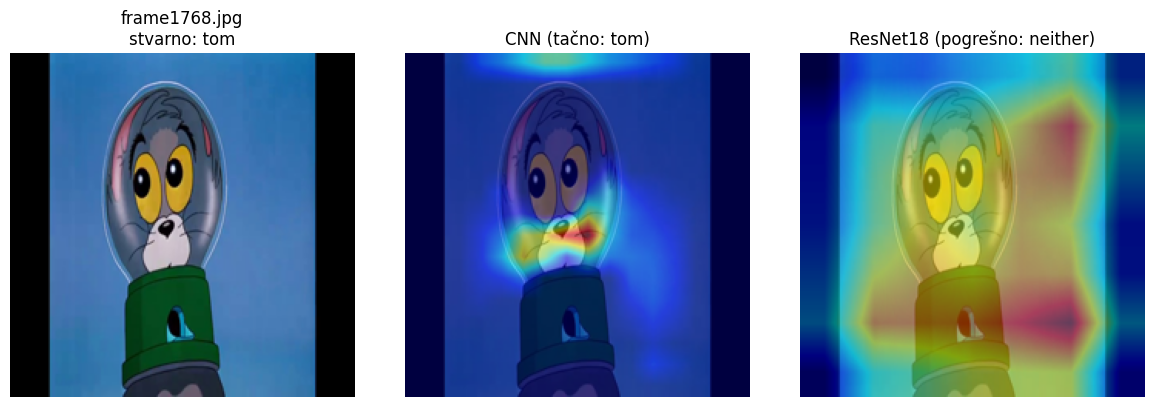

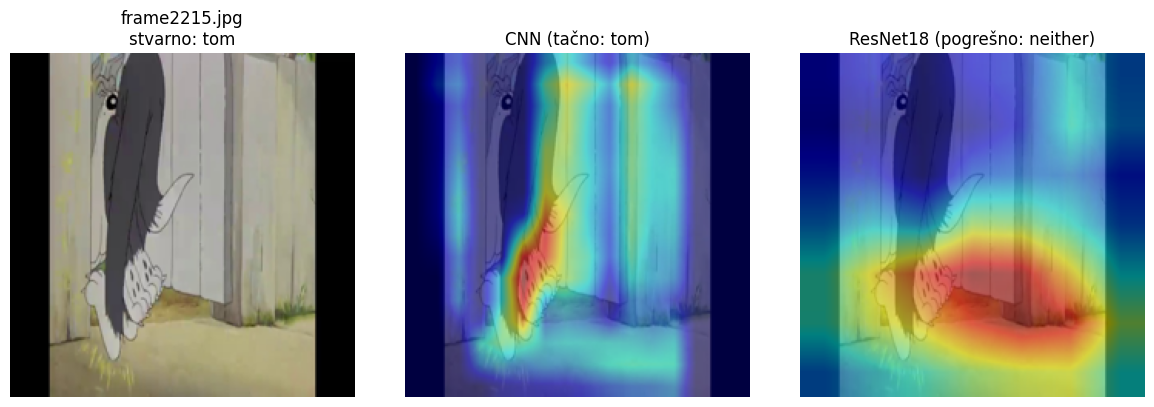

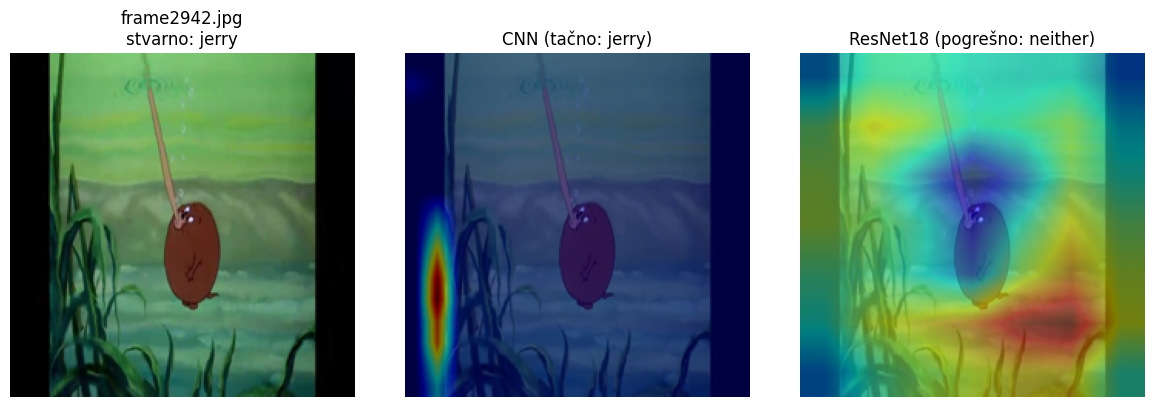

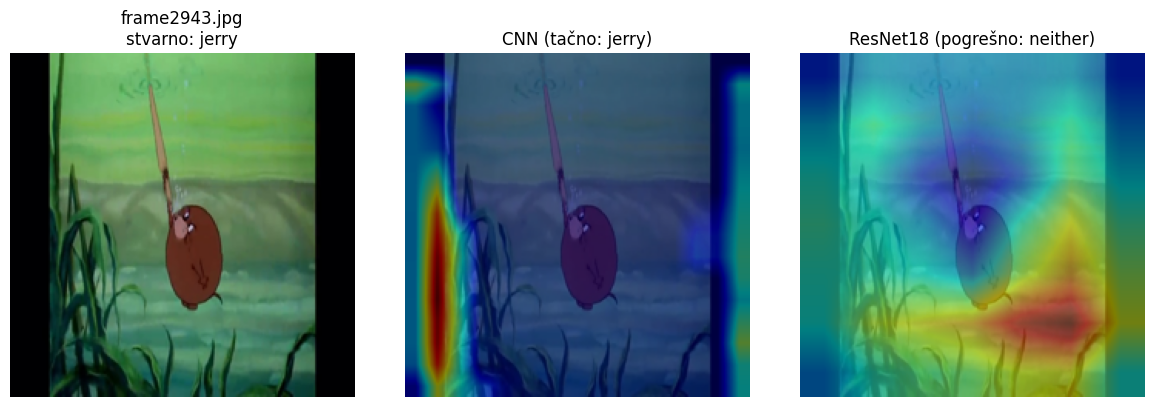

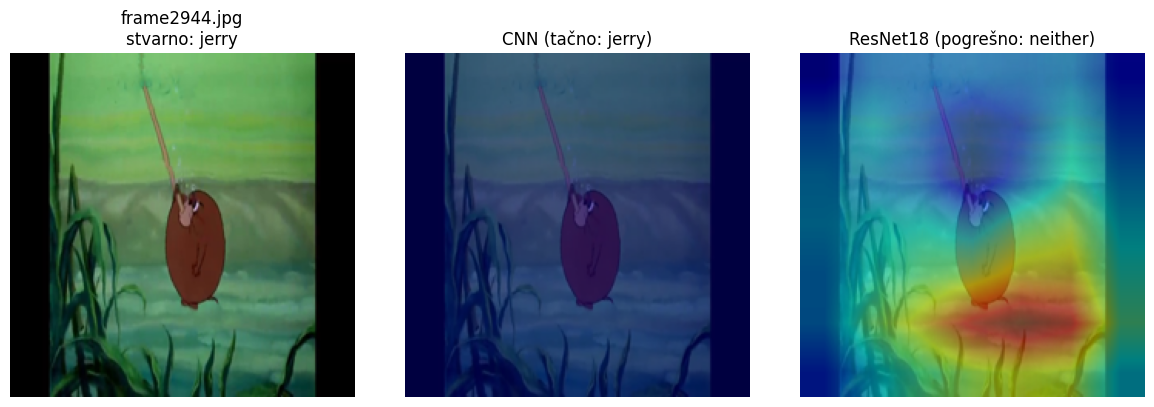

In [9]:
import matplotlib.pyplot as plt
import os

os.makedirs('results/12_gradcam_cnn_vs_resnet', exist_ok=True)

res_idx_inv = {v: k for k, v in res_idx.items()}
cnn_idx_inv = {v: k for k, v in cnn_idx.items()}

for _, row in cnn_bolji.iterrows():
    img = Image.open(row['filepath']).convert('RGB')

    cnn_input = cnn_tf(img).unsqueeze(0).to(device)
    cam_cnn = grad_cam(cnn, cnn_input, cnn_idx_inv[row['pred_cnn']], cnn.conv3)

    res_input = res_tf(img).unsqueeze(0).to(device)
    cam_res = grad_cam(resnet, res_input, res_idx_inv[row['pred_resnet']], resnet.layer4[-1])

    img_224 = np.array(img.resize((224, 224)))

    heatmap_cnn = cv2.applyColorMap(np.uint8(255 * cam_cnn), cv2.COLORMAP_JET)
    heatmap_cnn = cv2.cvtColor(heatmap_cnn, cv2.COLOR_BGR2RGB)
    overlay_cnn = (0.5 * img_224 + 0.5 * heatmap_cnn).astype(np.uint8)

    heatmap_res = cv2.applyColorMap(np.uint8(255 * cam_res), cv2.COLORMAP_JET)
    heatmap_res = cv2.cvtColor(heatmap_res, cv2.COLOR_BGR2RGB)
    overlay_res = (0.5 * img_224 + 0.5 * heatmap_res).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_224); axes[0].set_title(f"{row['filename']}\nstvarno: {row['class']}"); axes[0].axis('off')
    axes[1].imshow(overlay_cnn); axes[1].set_title(f"CNN (tačno: {row['pred_cnn']})"); axes[1].axis('off')
    axes[2].imshow(overlay_res); axes[2].set_title(f"ResNet18 (pogrešno: {row['pred_resnet']})"); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f"results/12_gradcam_cnn_vs_resnet/gradcam_{row['filename'].replace('.jpg','')}.png", dpi=150, bbox_inches='tight')
    plt.show()

Grad-CAM za oba modela i na 3 obrnuta slučaja (ResNet tačno, CNN pogrešno) — za potpuno poređenje.

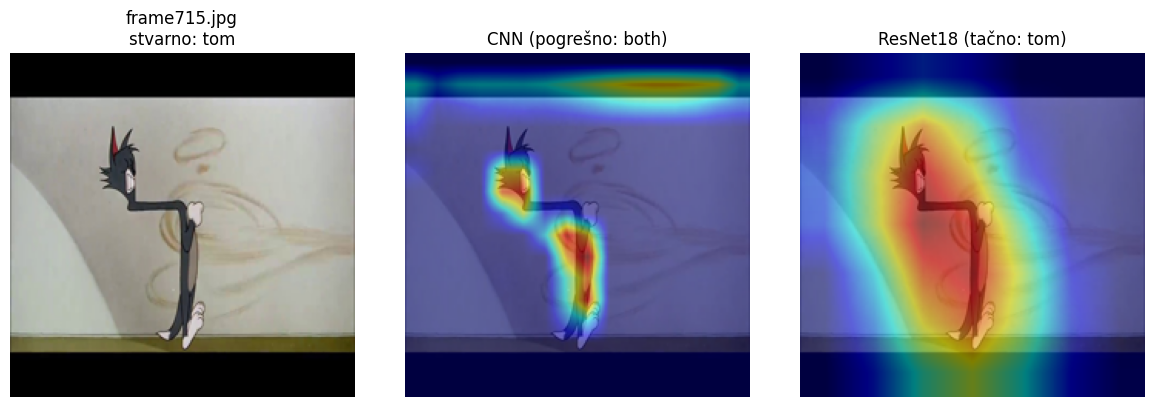

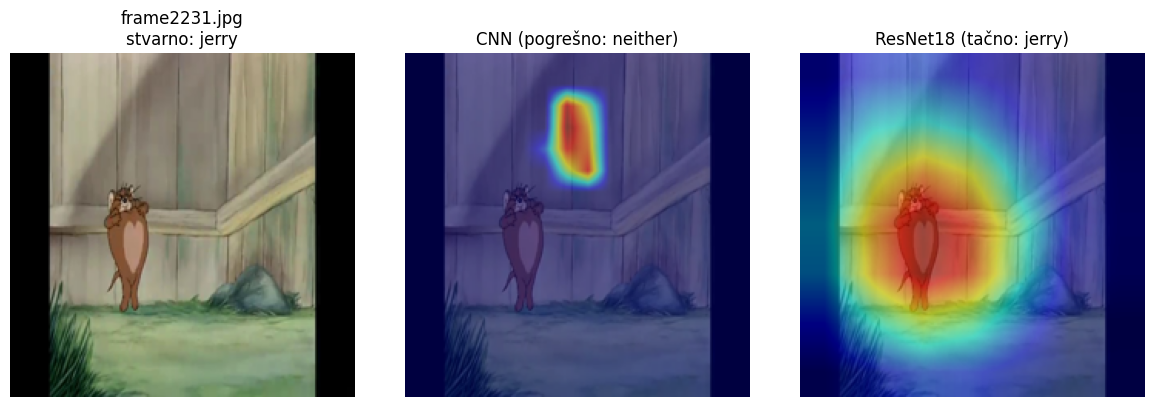

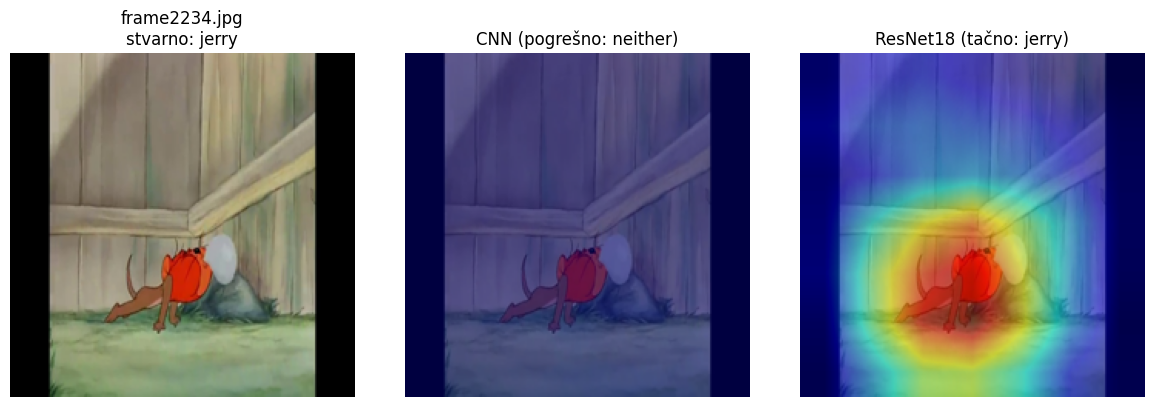

In [10]:
for _, row in resnet_bolji.iterrows():
    img = Image.open(row['filepath']).convert('RGB')

    cnn_input = cnn_tf(img).unsqueeze(0).to(device)
    cam_cnn = grad_cam(cnn, cnn_input, cnn_idx_inv[row['pred_cnn']], cnn.conv3)

    res_input = res_tf(img).unsqueeze(0).to(device)
    cam_res = grad_cam(resnet, res_input, res_idx_inv[row['pred_resnet']], resnet.layer4[-1])

    img_224 = np.array(img.resize((224, 224)))

    heatmap_cnn = cv2.applyColorMap(np.uint8(255 * cam_cnn), cv2.COLORMAP_JET)
    heatmap_cnn = cv2.cvtColor(heatmap_cnn, cv2.COLOR_BGR2RGB)
    overlay_cnn = (0.5 * img_224 + 0.5 * heatmap_cnn).astype(np.uint8)

    heatmap_res = cv2.applyColorMap(np.uint8(255 * cam_res), cv2.COLORMAP_JET)
    heatmap_res = cv2.cvtColor(heatmap_res, cv2.COLOR_BGR2RGB)
    overlay_res = (0.5 * img_224 + 0.5 * heatmap_res).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_224); axes[0].set_title(f"{row['filename']}\nstvarno: {row['class']}"); axes[0].axis('off')
    axes[1].imshow(overlay_cnn); axes[1].set_title(f"CNN (pogrešno: {row['pred_cnn']})"); axes[1].axis('off')
    axes[2].imshow(overlay_res); axes[2].set_title(f"ResNet18 (tačno: {row['pred_resnet']})"); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig(f"results/12_gradcam_cnn_vs_resnet/gradcam_obrnuto_{row['filename'].replace('.jpg','')}.png", dpi=150, bbox_inches='tight')
    plt.show()

### Zaključak

- Od 32 slike u `challenges.csv`, pronađeno je **5 slika gdje CNN pogađa a ResNet18 griješi**, i **3 slike
  gdje je obrnuto** (ResNet pogađa, CNN griješi).
- U svih 8 tih grešaka, nijedan model nije pobrkao tom↔jerry međusobno — umjesto toga predviđao je
  `both` ili `neither`, kao da "odustaje" kad je nesiguran, umjesto da pogodi pogrešan lik.
- Grad-CAM poređenje pokazuje precizniji obrazac od početne pretpostavke: **nije da CNN doslijedno
  koristi pozadinu a ResNet samo lik** — umjesto toga, u slikama gdje CNN pogađa, ResNet-ov fokus je
  bio difuzan/razliven (pokrivao je i pozadinu, bez jasnog centra), dok je CNN bio uže i tačnije
  fokusiran na lik (na njušku, šape). U slikama gdje ResNet pogađa, obrazac se OKREĆE — ResNet je oštro i tačno centriran
  na lik, dok je CNN-ov fokus bio slab, razliven, ili pogrešno usmjeren (na mrlju/ogradu u pozadini).
- **Pravilo koje se izdvaja:** koji god model ima OŠTAR, dobro centriran fokus na liku u datom
  primjeru, taj i pogodi tačnu klasu — bez obzira koji je model. Razlika u performansi ne dolazi od
  toga da jedan model "uvijek gleda pozadinu", nego od toga koliko je fokus tog modela, na tom
  konkretnom primjeru, precizno pogodio lik.
- **Napomena:** uzorak je mali (5+3=8 slika od ukupno 32), a i ukupna razlika u macro-F1 na
  `challenges.csv` je mala (CNN 0.874 vs ResNet18 0.846, iz notebook-a 07).

Bonus eksperiment — vještačka slika (obična pozadina + mala braon "elipsa", bez ikakvog oblika miša/ušiju/repa) da provjerimo da li model "prečicom" kaže jerry samo na osnovu boje/veličine.

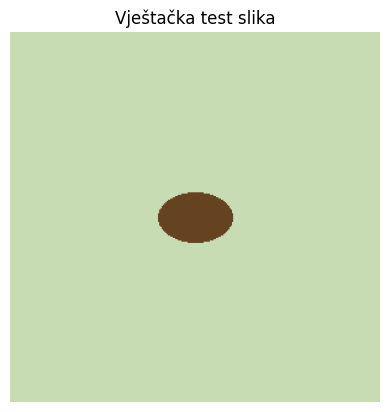

In [11]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

test_img = Image.new('RGB', (300, 300), color=(200, 220, 180))  # blijedozelena pozadina
draw = ImageDraw.Draw(test_img)
draw.ellipse([120, 130, 180, 170], fill=(101, 67, 33))  # mala braon elipsa - NIJE oblik jerry-ja

plt.imshow(test_img)
plt.axis('off')
plt.title('Vještačka test slika')
plt.show()

Predikcija CNN-a i ResNet-a na vještačkoj slici — da li kažu "jerry" samo na osnovu boje/veličine.

In [12]:
with torch.no_grad():
    out_cnn = cnn(cnn_tf(test_img).unsqueeze(0).to(device))
    pred_test_cnn = cnn_idx[out_cnn.argmax(1).item()]

    out_res = resnet(res_tf(test_img).unsqueeze(0).to(device))
    pred_test_res = res_idx[out_res.argmax(1).item()]

print("CNN predviđa:", pred_test_cnn)
print("ResNet18 predviđa:", pred_test_res)

CNN predviđa: jerry
ResNet18 predviđa: neither


### Bonus — zaključak

Vještačka slika (obična braon elipsa, bez oblika miša) je dala jasan rezultat: **CNN je pogrešno rekao
"jerry"**, dok je **ResNet18 tačno rekao "neither"**. Ovo je konkretan dokaz da CNN (treniran od nule,
na malom skupu, bez predznanja) može naučiti prečicu "mala braon mrlja = jerry" umjesto stvarnog oblika
miša, dok je ResNet18 (zahvaljujući ImageNet predtreningu) otporniji na ovu vrstu greške.

In [13]:
!git add results/12_gradcam_cnn_vs_resnet/
!git commit -m "Dodaj Grad-CAM analizu CNN vs ResNet18 na challenges slikama (notebook 12) - rezultati i vizualizacije"
!git push

[main 5c74236] Dodaj Grad-CAM analizu CNN vs ResNet18 na challenges slikama (notebook 12) - rezultati i vizualizacije
 8 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 results/12_gradcam_cnn_vs_resnet/gradcam_frame1768.png
 create mode 100644 results/12_gradcam_cnn_vs_resnet/gradcam_frame2215.png
 create mode 100644 results/12_gradcam_cnn_vs_resnet/gradcam_frame2942.png
 create mode 100644 results/12_gradcam_cnn_vs_resnet/gradcam_frame2943.png
 create mode 100644 results/12_gradcam_cnn_vs_resnet/gradcam_frame2944.png
 create mode 100644 results/12_gradcam_cnn_vs_resnet/gradcam_obrnuto_frame2231.png
 create mode 100644 results/12_gradcam_cnn_vs_resnet/gradcam_obrnuto_frame2234.png
 create mode 100644 results/12_gradcam_cnn_vs_resnet/gradcam_obrnuto_frame715.png
Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compression using up to 2 threads
Compressing objects: 100% (12/12), done.
Writing objects: 100% (12/12), 3.99 MiB | 9.99 MiB/s, done.